In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("AgroSmart AI Environment Ready 🚀")


AgroSmart AI Environment Ready 🚀


In [4]:
import pandas as pd

file_path = r"D:\AJN\NIBM\HDSE\IOT\AgroSmart\AI\Data\historical dataset\Crop_recommendation.csv"

df = pd.read_csv(file_path)

print("Dataset Loaded Successfully ✅")
df.head()


Dataset Loaded Successfully ✅


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [5]:
print("Shape of dataset:", df.shape)
print("\nColumns in dataset:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
df.head()


Shape of dataset: (2200, 8)

Columns in dataset:
Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

Data types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

First 5 rows:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [6]:
# Drop soil nutrient columns (not available in AgroSmart sensors)
df_model = df.drop(columns=['N', 'P', 'K'])

print("Columns used for AgroSmart AI:")
print(df_model.columns)


Columns used for AgroSmart AI:
Index(['temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')


In [7]:
# Features and target
X = df_model.drop('label', axis=1)
y = df_model['label']

print("Input shape:", X.shape)
print("Output shape:", y.shape)


Input shape: (2200, 4)
Output shape: (2200,)


In [8]:
# Group by crop and calculate mean environmental conditions
crop_patterns = df_model.groupby('label').mean()

crop_patterns


,temperature,humidity,ph,rainfall
label,,,,
apple,22.630942,92.333383,5.929663,112.654779
banana,27.376798,80.358123,5.983893,104.626980
blackgram,29.973340,65.118426,7.133952,67.884151
chickpea,18.872847,16.860439,7.336957,80.058977
coconut,27.409892,94.844272,5.976562,175.686646
coffee,25.540477,58.869846,6.790308,158.066295
cotton,23.988958,79.843474,6.912675,80.398043
grapes,23.849575,81.875228,6.025937,69.611829
jute,24.958376,79.639864,6.732778,174.792798


In [9]:
# Select only the 3 crops for AgroSmart analysis
selected_crops = ['kidneybeans', 'mungbean', 'chickpea']

crop_patterns_3 = crop_patterns.loc[selected_crops]

crop_patterns_3


,temperature,humidity,ph,rainfall
label,,,,
kidneybeans,20.115085,21.605357,5.749411,105.919778
mungbean,28.525775,85.499975,6.723957,48.403601
chickpea,18.872847,16.860439,7.336957,80.058977


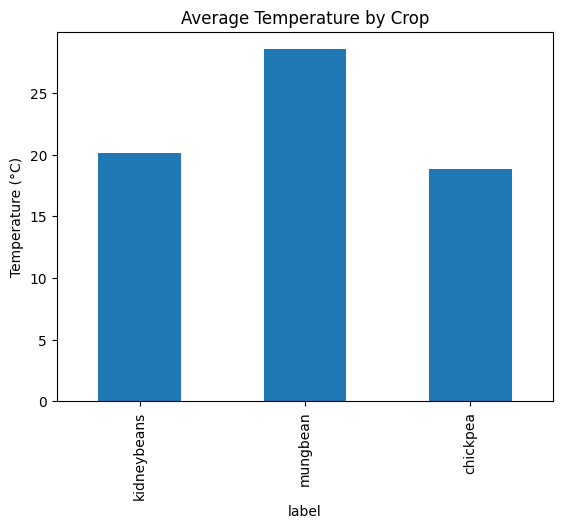

In [10]:
crop_patterns_3['temperature'].plot(kind='bar', title='Average Temperature by Crop')
plt.ylabel("Temperature (°C)")
plt.show()


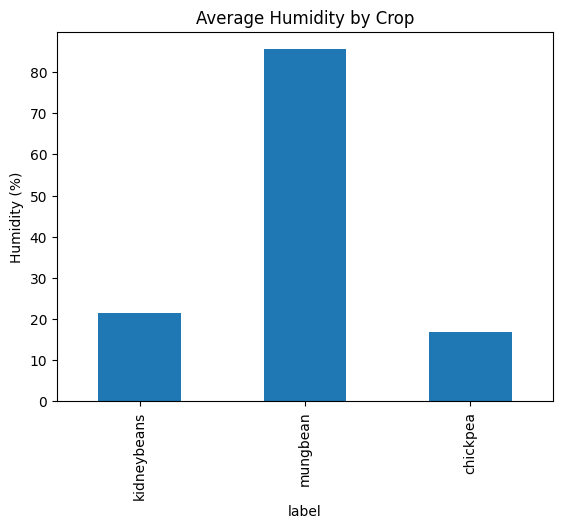

In [11]:
crop_patterns_3['humidity'].plot(kind='bar', title='Average Humidity by Crop')
plt.ylabel("Humidity (%)")
plt.show()


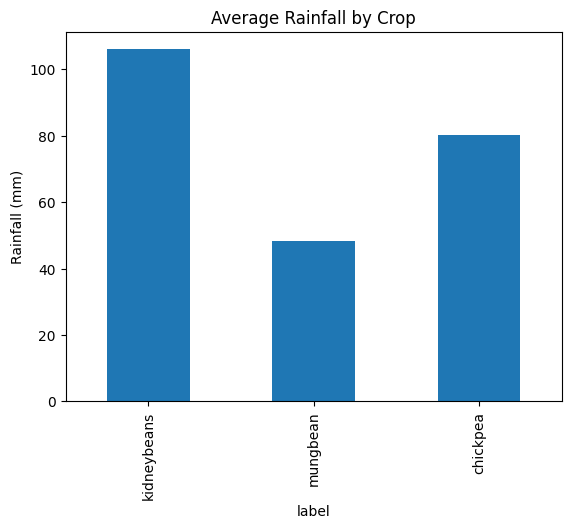

In [12]:
crop_patterns_3['rainfall'].plot(kind='bar', title='Average Rainfall by Crop')
plt.ylabel("Rainfall (mm)")
plt.show()


In [13]:
current_conditions = {
    "temperature": 26,
    "humidity": 60,
    "rainfall": 90,
    "ph": 6.5
}


In [14]:
for crop in crop_patterns_3.index:
    temp_diff = abs(current_conditions['temperature'] - crop_patterns_3.loc[crop, 'temperature'])
    hum_diff = abs(current_conditions['humidity'] - crop_patterns_3.loc[crop, 'humidity'])
    rain_diff = abs(current_conditions['rainfall'] - crop_patterns_3.loc[crop, 'rainfall'])

    score = temp_diff + hum_diff + rain_diff

    print(f"{crop} suitability score (lower is better): {score:.2f}")


kidneybeans suitability score (lower is better): 60.20
mungbean suitability score (lower is better): 69.62
chickpea suitability score (lower is better): 60.21


In [1]:
import pandas as pd
import json

# Load dataset
df = pd.read_csv(r"D:\AJN\NIBM\HDSE\IOT\AgroSmart\AI\Data\historical dataset\Crop_recommendation.csv")

# Create mean patterns per crop using ALL input columns
patterns = df.groupby("label")[["N","P","K","temperature","humidity","ph","rainfall"]].mean()

# Convert to JSON dictionary
patterns_json = patterns.to_dict(orient="index")

# Save to a JSON file (you will paste this into dashboard later)
output_path = r"D:\AJN\NIBM\HDSE\IOT\AgroSmart\AI\Data\historical dataset\agrosmart_crop_patterns.json"
with open(output_path, "w") as f:
    json.dump(patterns_json, f, indent=2)

print("✅ Patterns JSON created and saved at:")
print(output_path)

# Preview first 3 crops
list(patterns_json.items())[:3]



✅ Patterns JSON created and saved at:
D:\AJN\NIBM\HDSE\IOT\AgroSmart\AI\Data\historical dataset\agrosmart_crop_patterns.json


[('apple',
  {'N': 20.8,
   'P': 134.22,
   'K': 199.89,
   'temperature': 22.6309424132,
   'humidity': 92.3333828756,
   'ph': 5.929662931809999,
   'rainfall': 112.654779275}),
 ('banana',
  {'N': 100.23,
   'P': 82.01,
   'K': 50.05,
   'temperature': 27.3767983057,
   'humidity': 80.35812258109999,
   'ph': 5.98389318024,
   'rainfall': 104.6269804001}),
 ('blackgram',
  {'N': 40.02,
   'P': 67.47,
   'K': 19.24,
   'temperature': 29.9733396789,
   'humidity': 65.1184255887,
   'ph': 7.13395162948,
   'rainfall': 67.8841511832})]

In [2]:
selected_crops = ["chickpea", "kidneybeans", "mungbean"]

patterns_3 = patterns.loc[selected_crops]  # patterns is the groupby mean table
patterns_3


,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
kidneybeans,20.75,67.54,20.05,20.115085,21.605357,5.749411,105.919778
mungbean,20.99,47.28,19.87,28.525775,85.499975,6.723957,48.403601


In [3]:
import json

patterns_3_json = patterns_3.to_dict(orient="index")
patterns_3_json


{'chickpea': {'N': 40.09,
  'P': 67.79,
  'K': 79.92,
  'temperature': 18.8728467519,
  'humidity': 16.8604394237,
  'ph': 7.33695662374,
  'rainfall': 80.0589772605},
 'kidneybeans': {'N': 20.75,
  'P': 67.54,
  'K': 20.05,
  'temperature': 20.1150846851,
  'humidity': 21.6053567295,
  'ph': 5.749410585870001,
  'rainfall': 105.91977754210001},
 'mungbean': {'N': 20.99,
  'P': 47.28,
  'K': 19.87,
  'temperature': 28.5257747353,
  'humidity': 85.49997454300001,
  'ph': 6.72395694037,
  'rainfall': 48.403600902899996}}

In [4]:
output_path_3 = r"D:\AJN\NIBM\HDSE\IOT\AgroSmart\AI\Data\historical dataset\agrosmart_patterns_3crops.json"
with open(output_path_3, "w") as f:
    json.dump(patterns_3_json, f, indent=2)

print("✅ 3-crop patterns saved at:", output_path_3)


✅ 3-crop patterns saved at: D:\AJN\NIBM\HDSE\IOT\AgroSmart\AI\Data\historical dataset\agrosmart_patterns_3crops.json
